# Feature Representation Analysis

This notebook demonstrates a comprehensive comparison of different image feature representations for visual recognition tasks. We investigate how various feature extraction methods impact classification performance on the CIFAR-10 dataset.

## Overview

The CIFAR-10 dataset contains 50,000 training images and 10,000 test images across ten classes (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck). Each image is 32×32 pixels in color.

## Feature Representations Evaluated

1. **Raw Pixel Space** - Direct pixel intensity values
2. **Histogram of Oriented Gradients (HOG)** - Traditional computer vision features
3. **Convolutional Neural Network (CNN) Features**
    * Intermediate-level and high-level features from **pretrained** VGG-11
    * Intermediate-level and high-level features from **randomly initialized** VGG-11

## Methodology

We employ k-nearest neighbor classification with Euclidean distance to evaluate each representation method, providing a controlled comparison across feature spaces.

## 1. Setup & Imports

### Import modules

Import all required libraries and modules used throughout the analysis.

In [1]:
from src.dataset import download_cifar10_dataset, load_dataset_splits
from src.models import run_nearest_neighbor
from src.extract_feature import compute_or_load_features
from src.visualization import visualize_cifar_data, visualize_nearest_neighbors
from torchinfo import summary
from src.vgg_network import vgg11_bn, test_pretrained_vgg

### Download CIFAR-10 Dataset

First, we download the CIFAR-10 dataset. The dataset will be automatically saved to the `datasets/` directory.

In [2]:
dataset = download_cifar10_dataset()

✓ CIFAR-10 dataset already exists in ./../datasets/cifar-10-batches-py Skipping download.


### Load Training and Test Sets

Load the preprocessed training and test splits with proper normalization.

In [3]:
x_train, y_train, x_test, y_test = load_dataset_splits()

======> CIFAR-10 dataset loaded
Training set data shape: (50000, 3, 32, 32)
Training set label shape: (50000,)
Test set data shape: (10000, 3, 32, 32)
Test set label shape: (10000,)


### Dataset Visualization

Explore the dataset by visualizing sample images from each class.

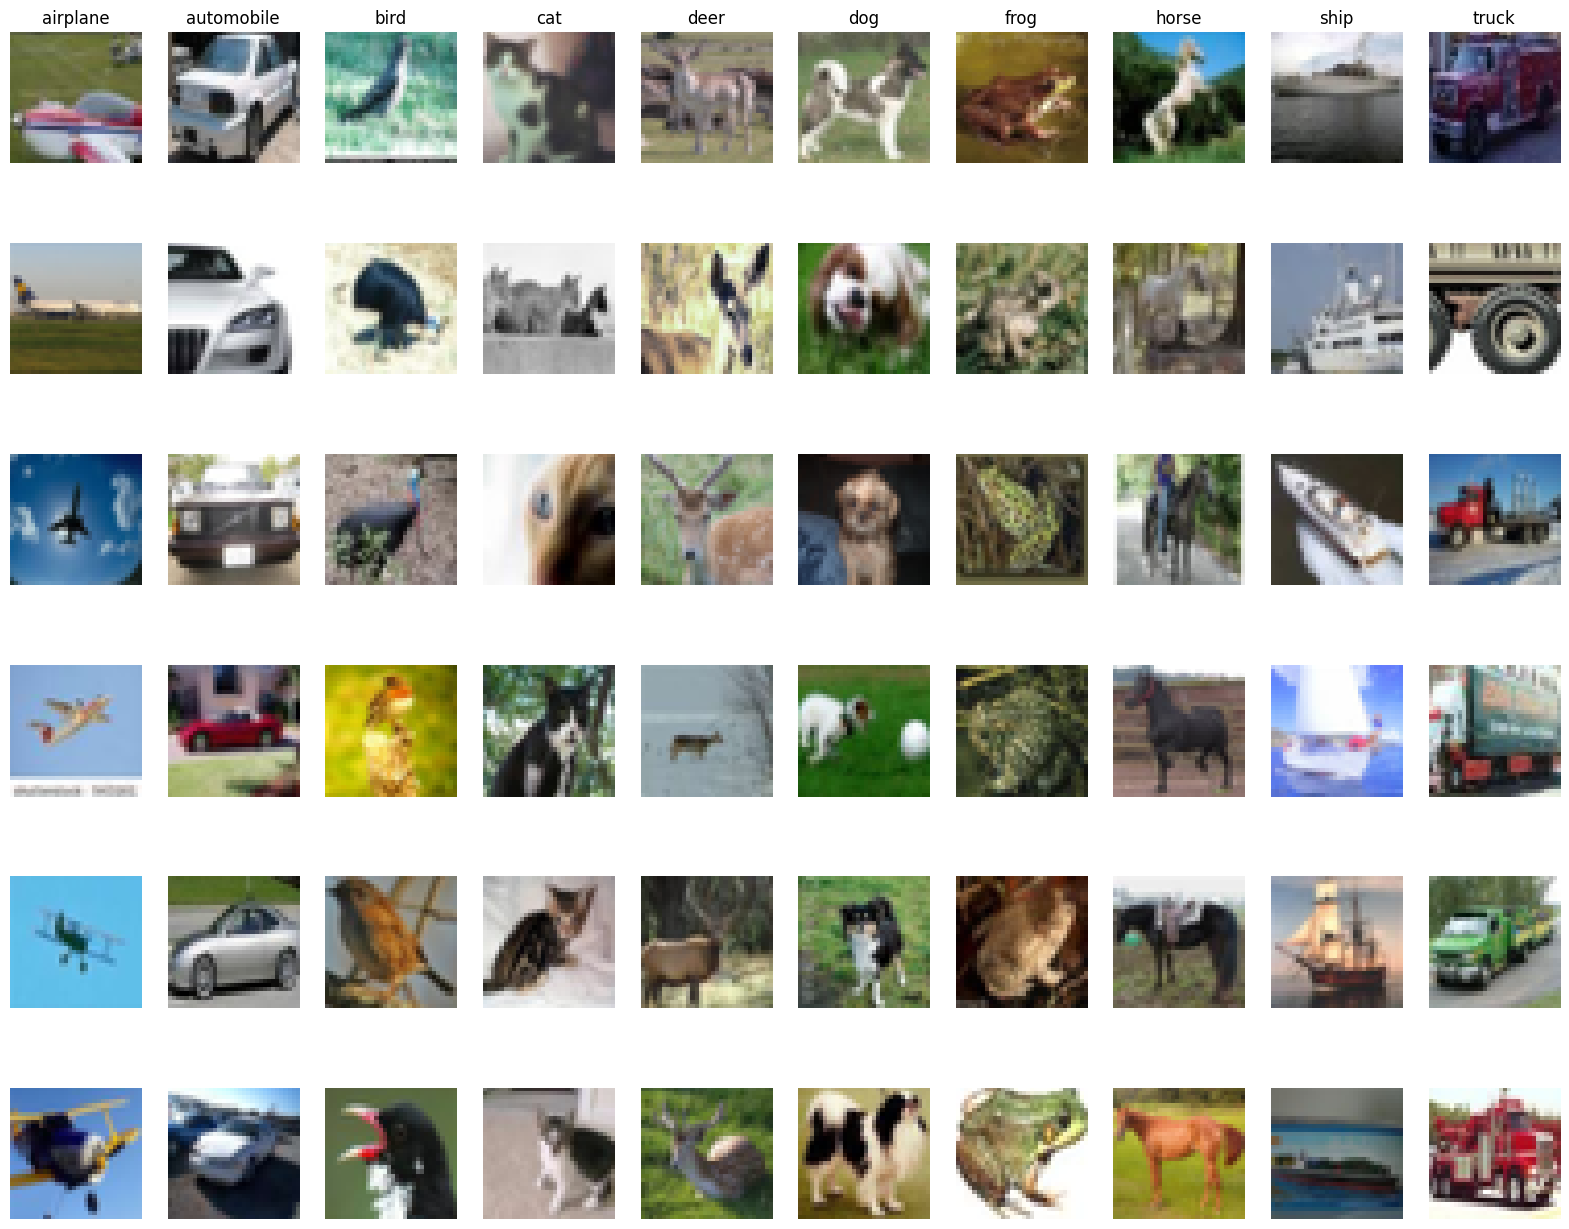

In [4]:
visualize_cifar_data(images=x_train.transpose(0, 2, 3, 1), labels=y_train, samples_per_class=6)

## 2. Nearest neighbor classification on CIFAR-10

In this part, we will investigate the classification problem by training and testing a nearest neighbor classifier on CIFAR-10 dataset with **Euclidean (L2) distance**. 

Function `run_nearest_neighbor`, shown in the next cell, takes a labeled training set (`x_train`, `y_train`) and test set (`x_test`, `y_test`), and applies 1-nearest neighbor classification to the test points, using `KNeighborsClassifier` from `sklearn`. It prints out the accuracy on the test set and returns the classifier.

### Nearest Neighbor on Raw Pixels

We perform nearest neighbor classification using **raw pixel representations** of the images.

Feature extraction is handled by the modular pipeline implemented in `src/extract_feature.py`. The function `compute_or_load_features` is used to generate or retrieve features for both training and test datasets.

**Feature types:**
- `'raw_pixel'` — flattened pixel values  
- `'hog'` — Histogram of Oriented Gradients features  
- `'pretrained_cnn'` — features from a pretrained CNN (VGG11)  
- `'random_cnn'` — features from a randomly initialized CNN  

**CNN layers:**
- `'last_conv'` — output of the final convolutional layer  
- `'last_fc'` — output of the final fully connected layer  

**Caching mechanism:**
To improve efficiency, extracted features are cached to disk. On the first run, features are computed and saved to the `features/` directory (path managed via `src/path.py`). On subsequent runs, existing files are detected and loaded directly, avoiding redundant computation.

**Benefits:**
- Reproducibility  
- Modular design  
- Efficient experimentation across feature representations  

======> Loaded train and test features from ./../features/raw_pixel.npz
Training feature shape: (50000, 3072)
Test feature shape: (10000, 3072)
Nearest neighbor accuracy on the test set: 0.353900


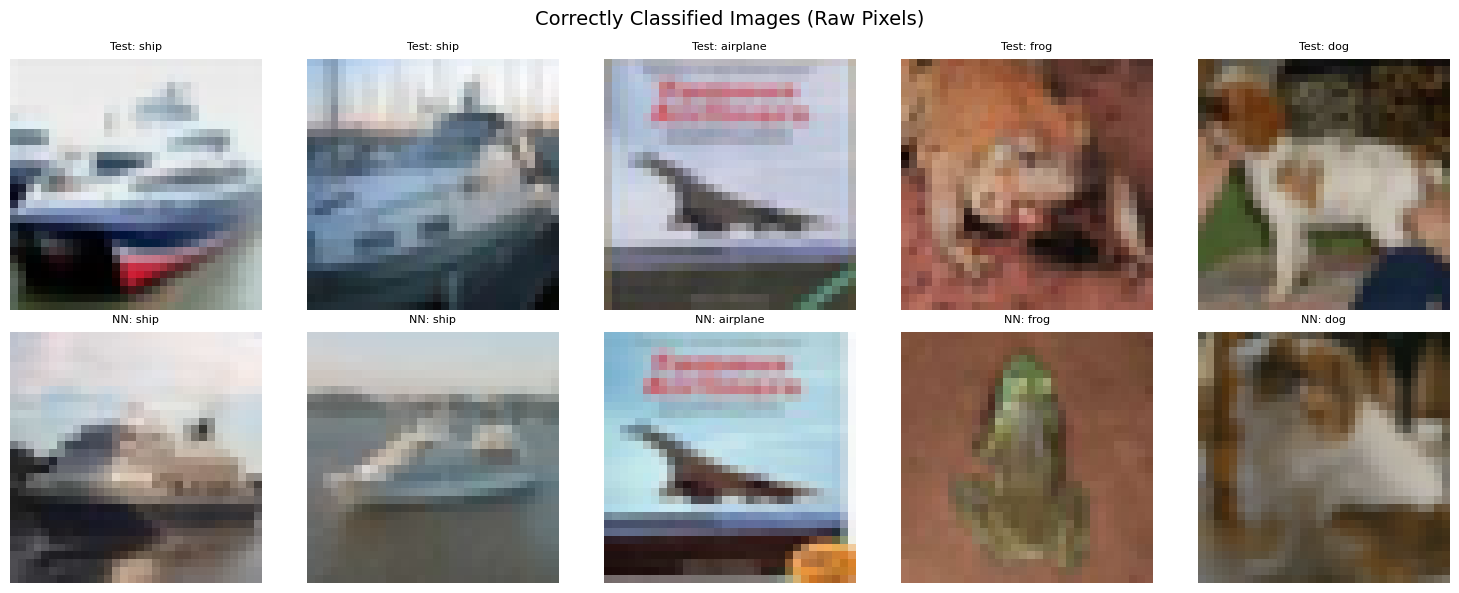

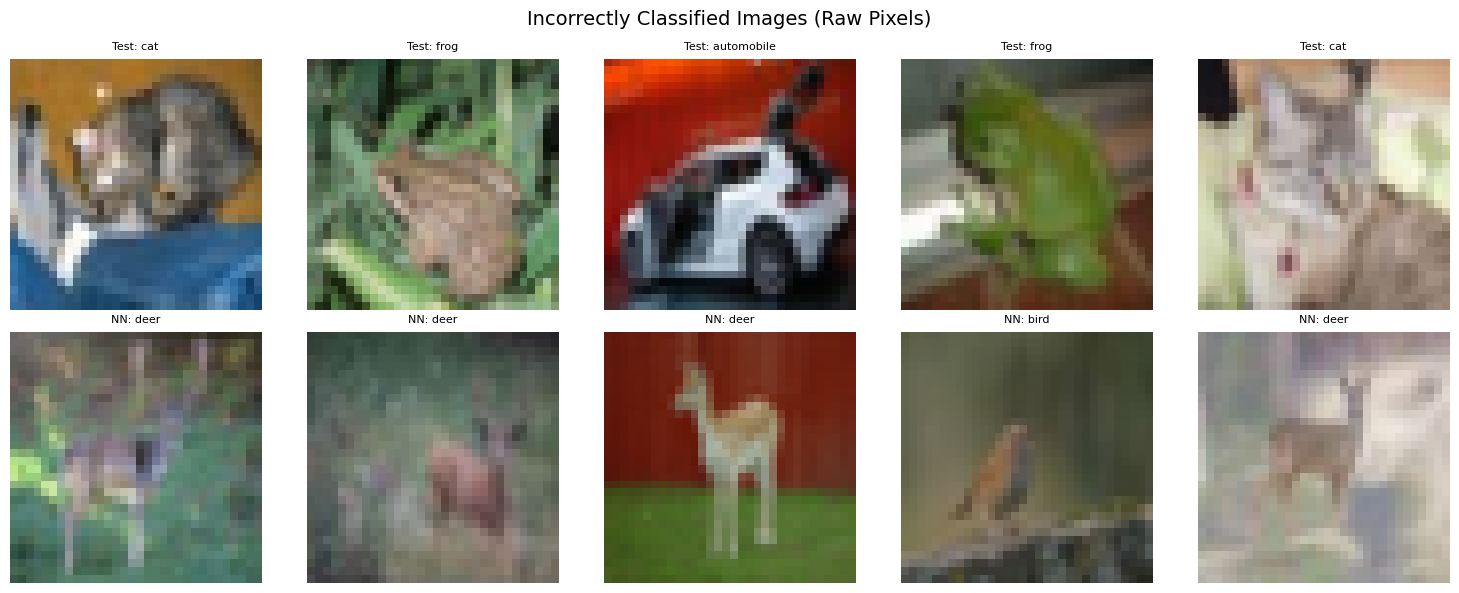

In [5]:
# compute or load features for raw pixel representation
raw_pixel_train_features, raw_pixel_test_features = compute_or_load_features(
    x_train, x_test, "raw_pixel"
)

# run knn classifier on raw pixel features and evaluate accuracy
raw_pixel_knn_classifier = run_nearest_neighbor(
    raw_pixel_train_features, y_train, raw_pixel_test_features, y_test
)

# visualize correctly and incorrectly classified images with their nearest neighbors
visualize_nearest_neighbors(
    x_test, y_test, x_train, y_train, 
    raw_pixel_knn_classifier, raw_pixel_test_features, 
    feature_name="Raw Pixels"
)

### Nearest neighbor on HOG features 
The HOG (Histogram of Oriented Gradients) descriptor computes local statistics of gradients in an image and uses them as feature respresentations.

======> Loaded train and test features from ./../features/hog.npz
Training feature shape: (50000, 512)
Test feature shape: (10000, 512)
Nearest neighbor accuracy on the test set: 0.365700


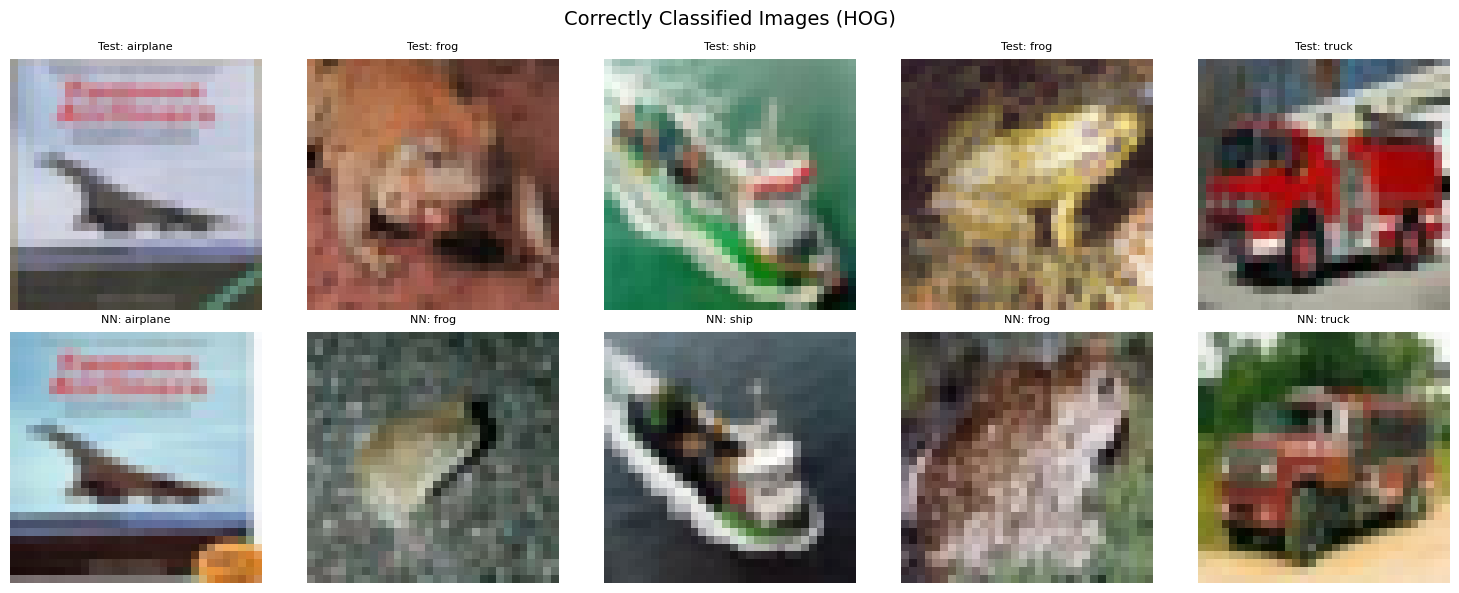

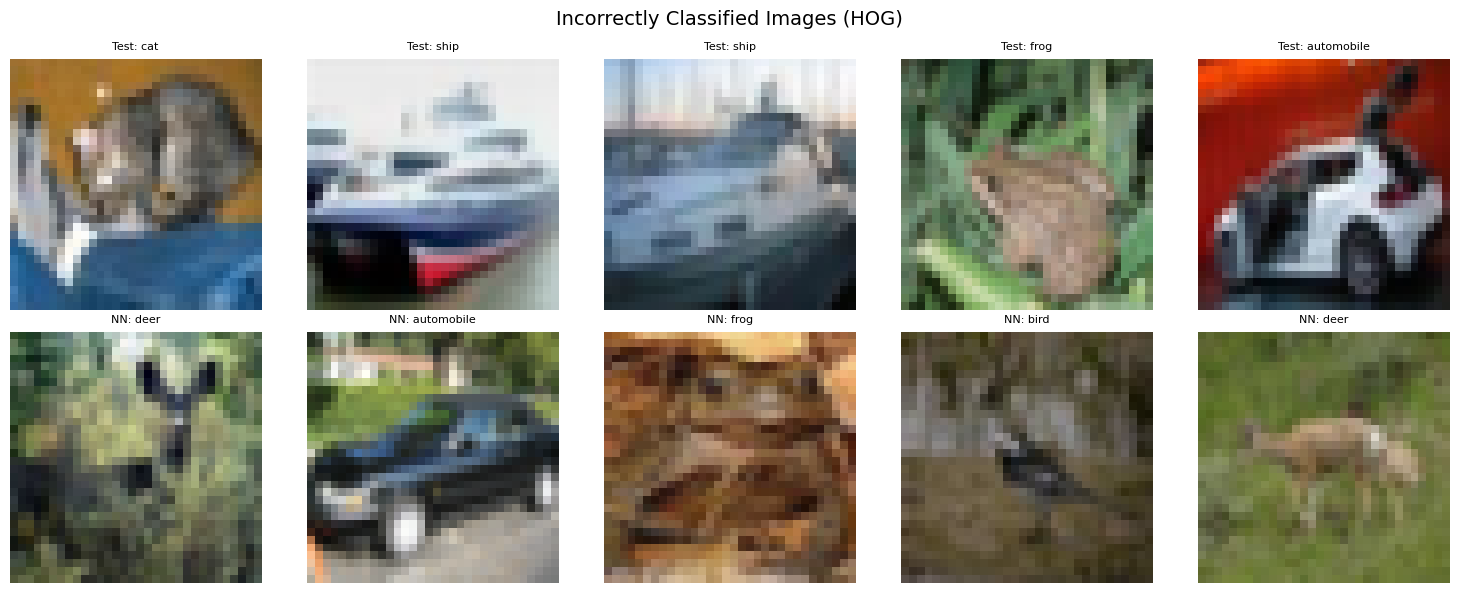

In [6]:
# compute or load features for HOG representation
hog_train_features, hog_test_features = compute_or_load_features(x_train, x_test, "hog")

# run knn classifier on HOG features and evaluate accuracy
hog_knn_classifier = run_nearest_neighbor(hog_train_features, y_train, hog_test_features, y_test)

# visualize correctly and incorrectly classified images with their nearest neighbors
visualize_nearest_neighbors(
    x_test, y_test, x_train, y_train,
    hog_knn_classifier, hog_test_features,
    feature_name="HOG"
)

## 3. Nearest Neighbor on CNN Features

Deep *convolutional neural networks* (CNNs) have become fundamental components in modern computer vision systems. When trained on large-scale image datasets, CNNs learn hierarchical feature representations, ranging from low-level edges to high-level semantic concepts.

In this section, we analyze feature representations extracted from different layers of a CNN.

**Model:**
We use the VGG11 architecture ([Simonyan & Zisserman, 2014](https://arxiv.org/abs/1409.1556)). A pretrained model on CIFAR-10 is provided at `models/vgg11_bn.pt`, so no training is required.

**Computation setup:**
Since we only perform forward passes (feature extraction), a CPU is sufficient.

**Architecture overview:**
VGG11 consists of:
- Convolutional layers (feature extraction)
- Pooling layers (spatial reduction)
- Fully connected layers (high-level representation)

To inspect the architecture, a helper function is provided to visualize layer-wise input and output shapes. The following code performs a forward pass on a batch of 32×32×3 images and prints the model summary.

In [7]:
# test pretrained VGG model on CIFAR-10 dataset
vgg_model = vgg11_bn(pretrained=False)
summary(vgg_model, input_size=(16, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      [16, 10]                  --
├─Sequential: 1-1                        [16, 512, 1, 1]           --
│    └─Conv2d: 2-1                       [16, 64, 32, 32]          1,792
│    └─BatchNorm2d: 2-2                  [16, 64, 32, 32]          128
│    └─ReLU: 2-3                         [16, 64, 32, 32]          --
│    └─MaxPool2d: 2-4                    [16, 64, 16, 16]          --
│    └─Conv2d: 2-5                       [16, 128, 16, 16]         73,856
│    └─BatchNorm2d: 2-6                  [16, 128, 16, 16]         256
│    └─ReLU: 2-7                         [16, 128, 16, 16]         --
│    └─MaxPool2d: 2-8                    [16, 128, 8, 8]           --
│    └─Conv2d: 2-9                       [16, 256, 8, 8]           295,168
│    └─BatchNorm2d: 2-10                 [16, 256, 8, 8]           512
│    └─ReLU: 2-11                        [16, 256, 8, 8]           --


### Nearest neighbor on pretrained CNN features

As shown in the summary above, a VGG net consists of three components: 
1. A sequence of convolutional blocks (1-1 and 1-2)
2. Two fully connected blocks (2-30 to 2-35)
3. A single fully connected layer (2-36)

The first two components together act as a feature extractor. The convolutional blocks extract the low-level and intermediate-level features, and the fully connected blocks extract the high-level features. The third component is a single linear layer mapping the feature vectors to the classes therefore can be viewed as a linear classifier. 

In this problem, we will experiment with features extracted by a pretrained VGG net at two specific layers:
1. `last_conv`: AdaptiveAvgPool2d (1-2)
2. `last_fc`: ReLU (2-34)

#### Pretrained CNN - Last Conv

======> Loaded train and test features from ./../features/pretrained_cnn_last_conv.npz
Training feature shape: (50000, 25088)
Test feature shape: (10000, 25088)
Nearest neighbor accuracy on the test set: 0.595200


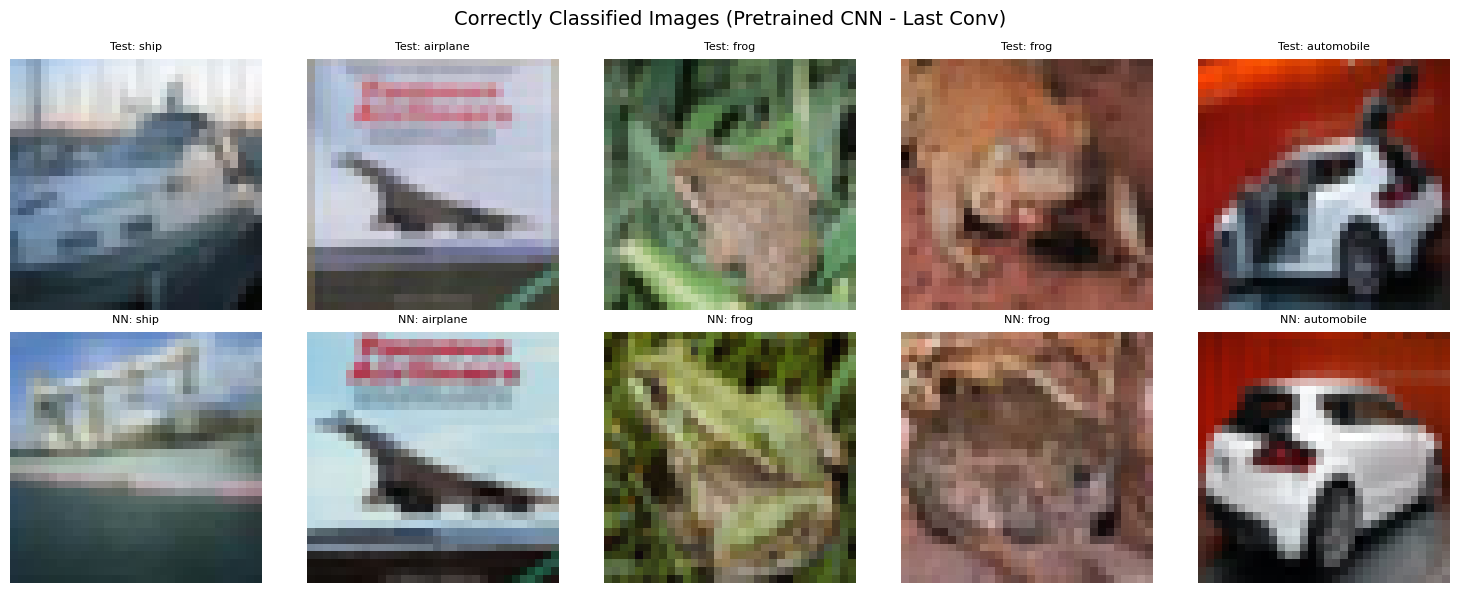

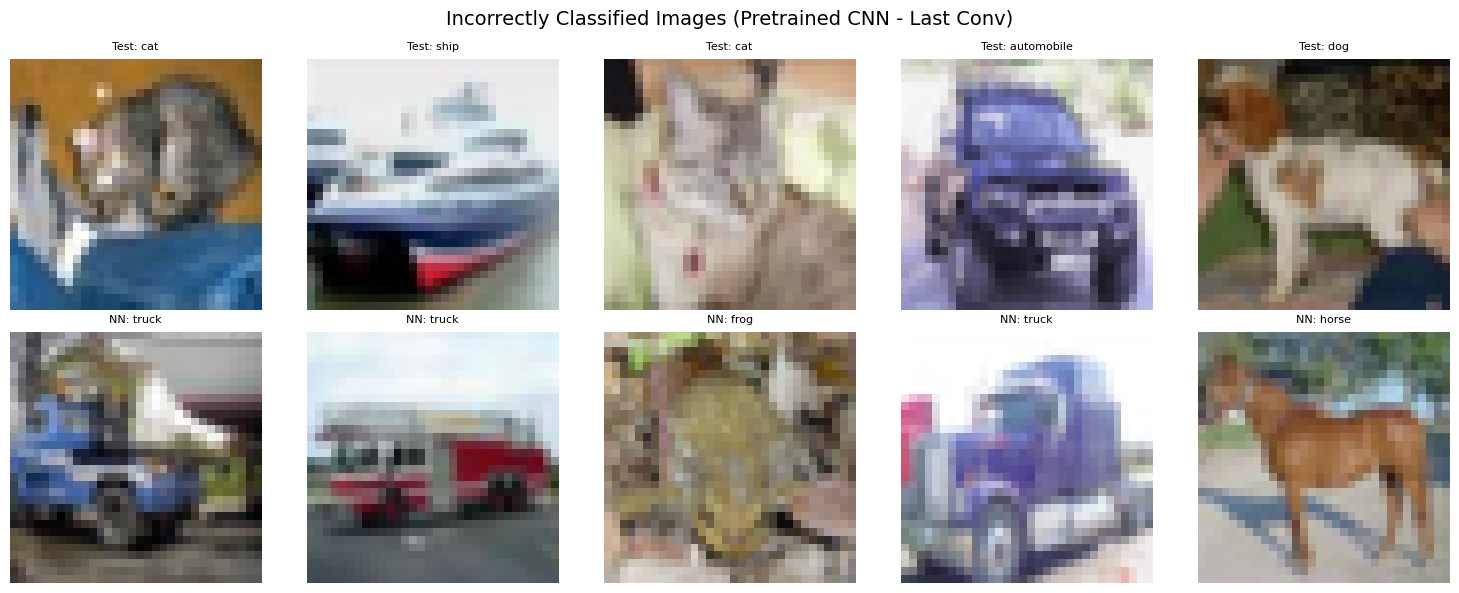

In [8]:
# compute or load features for pretrained CNN representation (last conv layer)
pretrained_cnn_train_features_last_conv, pretrained_cnn_test_features_last_conv = compute_or_load_features(
    x_train, x_test, "pretrained_cnn", layer="last_conv"
)

# run knn classifier on pretrained CNN features and evaluate accuracy
pretrained_cnn_knn_classifier_last_conv = run_nearest_neighbor(
    pretrained_cnn_train_features_last_conv, y_train, pretrained_cnn_test_features_last_conv, y_test
)

# visualize correctly and incorrectly classified images with their nearest neighbors
visualize_nearest_neighbors(
    x_test, y_test, x_train, y_train,
    pretrained_cnn_knn_classifier_last_conv, pretrained_cnn_test_features_last_conv,
    feature_name="Pretrained CNN - Last Conv"
)

#### Pretrained CNN - Last FC

======> Loaded train and test features from ./../features/pretrained_cnn_last_fc.npz
Training feature shape: (50000, 4096)
Test feature shape: (10000, 4096)
Nearest neighbor accuracy on the test set: 0.534300


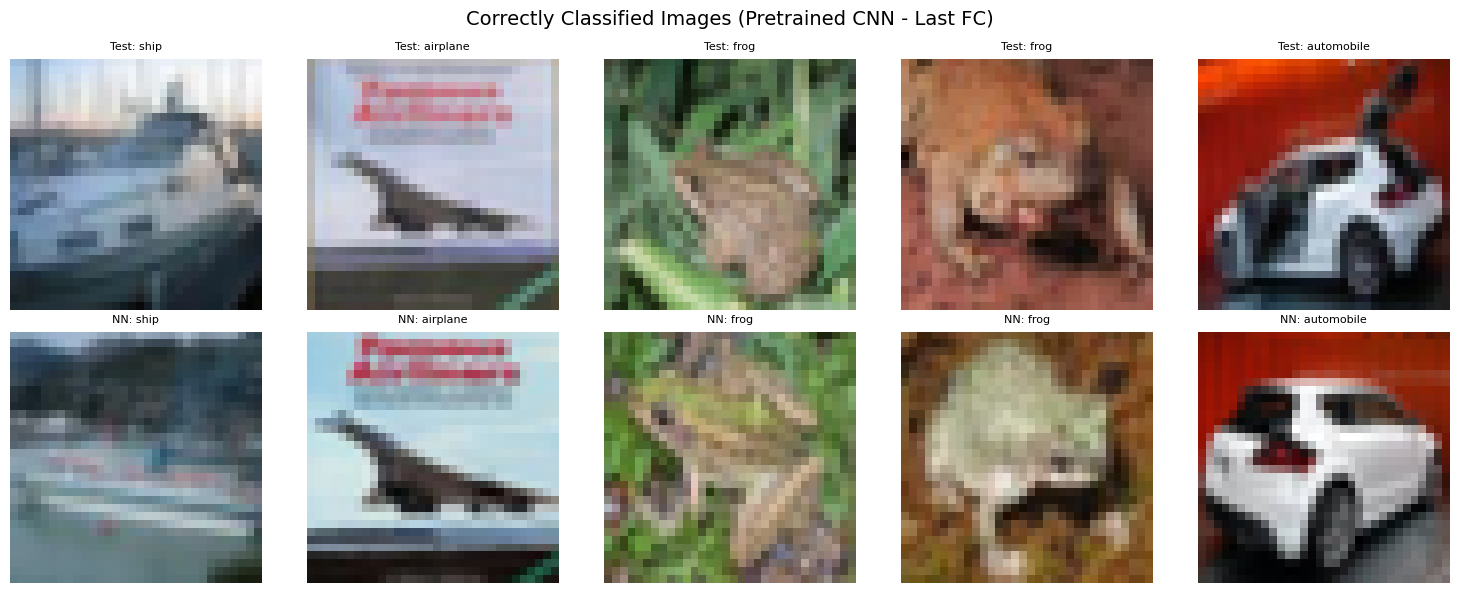

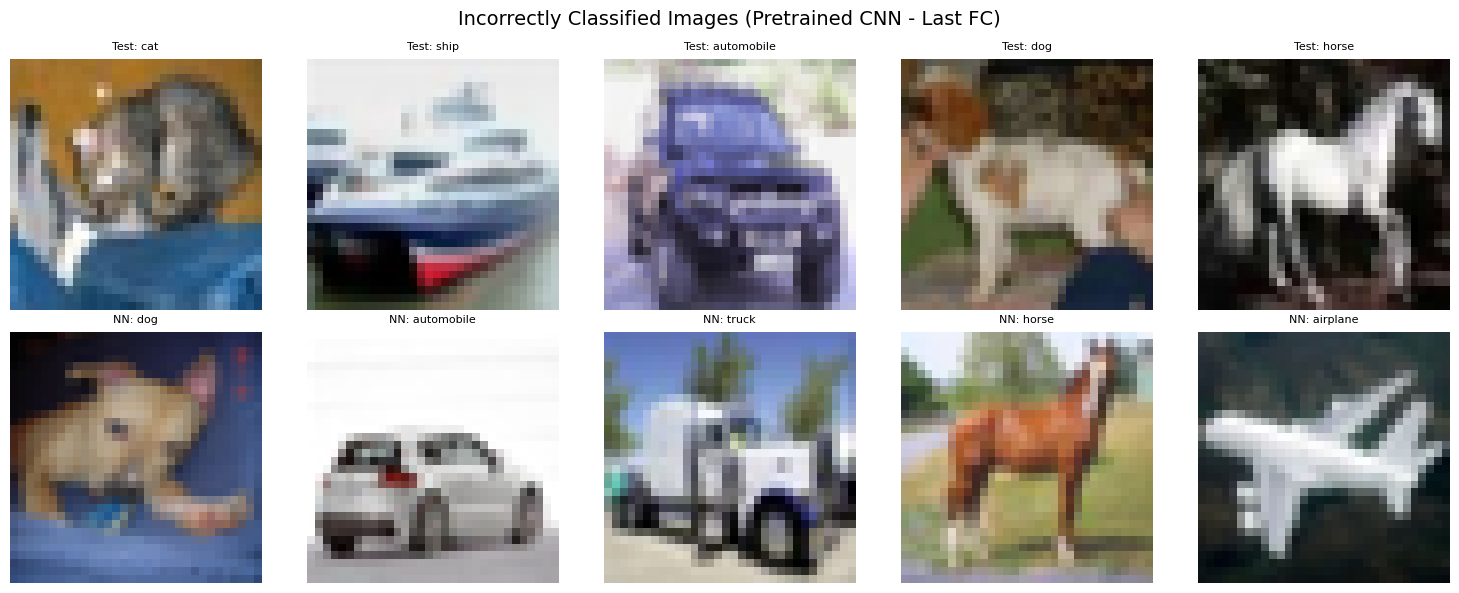

In [9]:
# compute or load features for pretrained CNN representation (last fc layer)
pretrained_cnn_train_features_last_fc, pretrained_cnn_test_features_last_fc = compute_or_load_features(
    x_train, x_test, "pretrained_cnn", layer="last_fc"
)

# run knn classifier on pretrained CNN features and evaluate accuracy
pretrained_cnn_knn_classifier_last_fc = run_nearest_neighbor(
    pretrained_cnn_train_features_last_fc, y_train, pretrained_cnn_test_features_last_fc, y_test
)

# visualize correctly and incorrectly classified images with their nearest neighbors
visualize_nearest_neighbors(
    x_test, y_test, x_train, y_train,
    pretrained_cnn_knn_classifier_last_fc, pretrained_cnn_test_features_last_fc,
    feature_name="Pretrained CNN - Last FC"
)

### Alignment Between the Nearest Neighbor Classifier and the Pretrained CNN

In this section, we evaluate the pretrained VGG model on the CIFAR-10 test set using `test_pretrained_vgg` from `src/vgg_network.py`. We then compare its test accuracy with the nearest neighbor classifier operating in the pretrained `last_conv` and `last_fc` feature spaces.

This comparison helps identify which representation yields behavior most similar to that of the pretrained CNN.

In [10]:
# test pretrained VGG model on CIFAR-10 dataset
test_acc = test_pretrained_vgg(x_test, y_test)
print('Accuracy on the test images: ', test_acc) 

Accuracy on the test images:  0.9225


### Nearest Neighbor on Random CNN Features

Convolutional neural networks (CNNs) are widely used for feature extraction in computer vision, often attributed to their training on large-scale datasets. However, recent work such as *Deep Image Prior* [1] suggests that the architecture of a CNN alone encodes strong inductive biases, even without training.

In this section, we investigate whether features extracted from a randomly initialized CNN can still be useful for image classification. Specifically, we evaluate the performance of a nearest neighbor classifier using features from a random CNN and compare it with pretrained representations.

This experiment helps assess the extent to which CNN architecture, independent of learned weights, contributes to effective feature representations.

#### Random CNN - Last Conv

======> Loaded train and test features from ./../features/random_cnn_last_conv.npz
Training feature shape: (50000, 25088)
Test feature shape: (10000, 25088)
Nearest neighbor accuracy on the test set: 0.406500


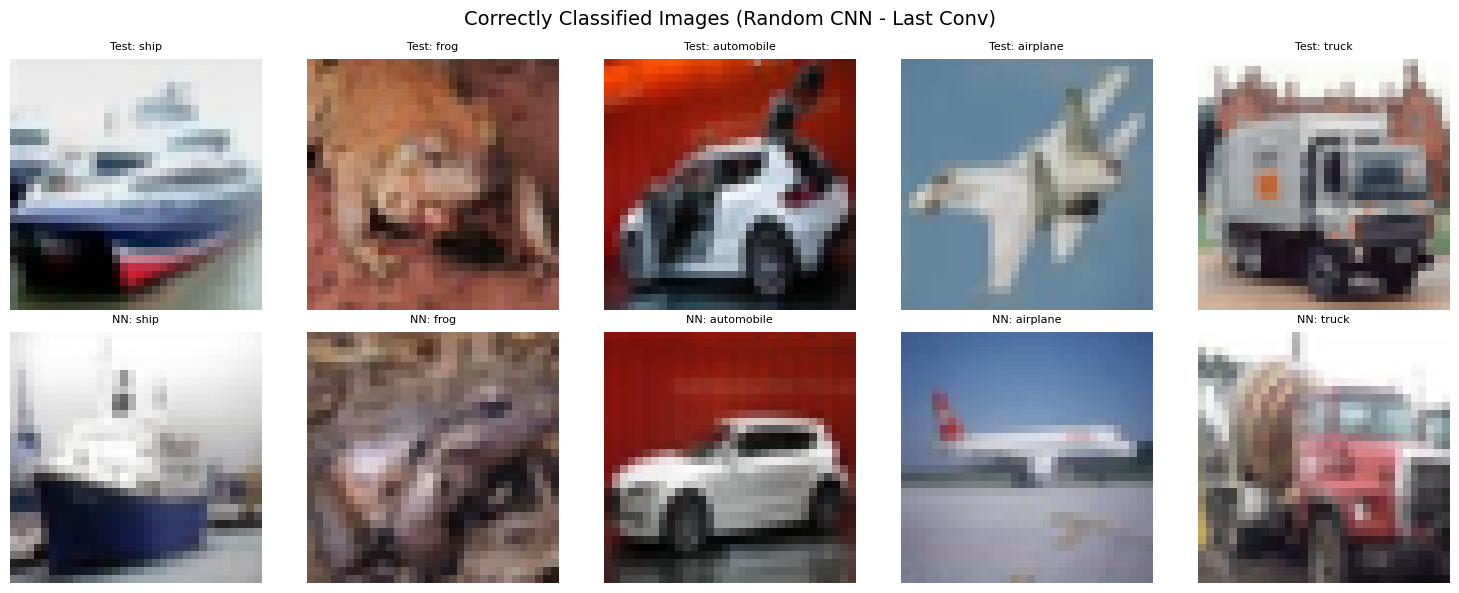

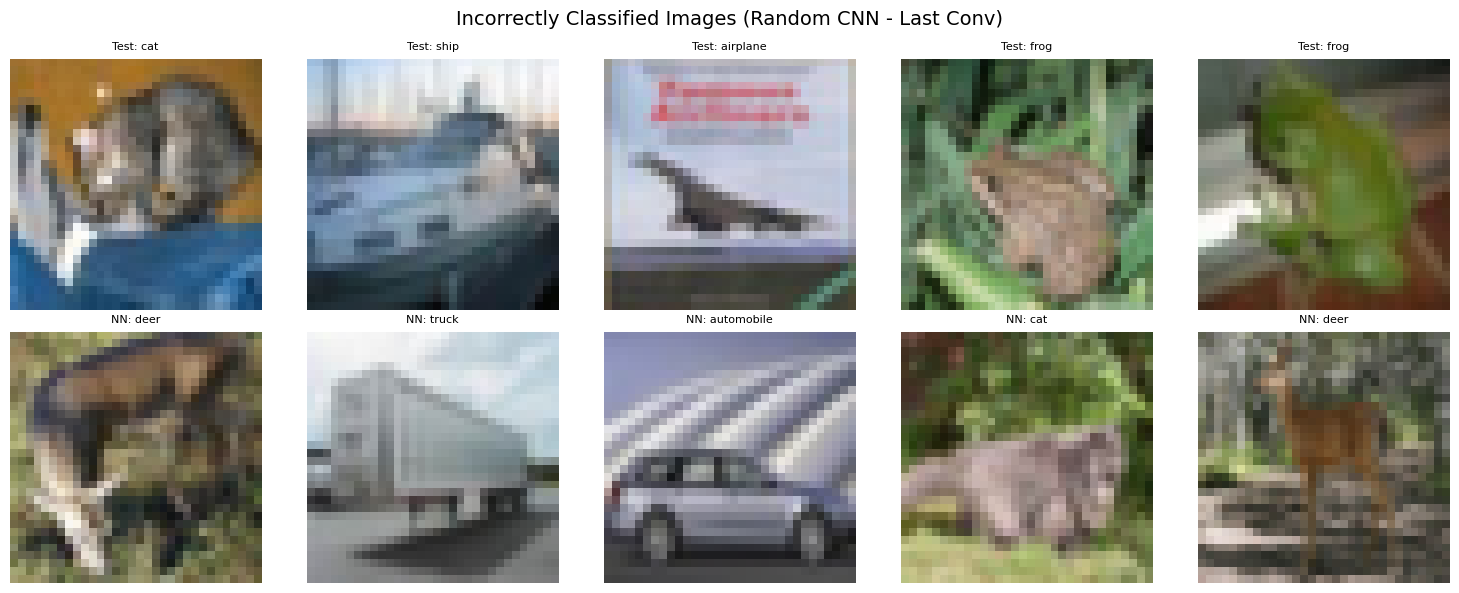

In [11]:
# compute or load features for random CNN at last_conv layer
random_cnn_train_features_last_conv, random_cnn_test_features_last_conv = compute_or_load_features(
    x_train, x_test, "random_cnn", layer="last_conv"
)

# run knn classifier on random CNN last_conv features and evaluate accuracy
random_cnn_knn_classifier_last_conv = run_nearest_neighbor(
    random_cnn_train_features_last_conv, y_train, random_cnn_test_features_last_conv, y_test
)

# visualize correctly and incorrectly classified images with their nearest neighbors
visualize_nearest_neighbors(
    x_test, y_test, x_train, y_train,
    random_cnn_knn_classifier_last_conv, random_cnn_test_features_last_conv,
    feature_name="Random CNN - Last Conv"
)

#### Random CNN - Last FC

======> Loaded train and test features from ./../features/random_cnn_last_fc.npz
Training feature shape: (50000, 4096)
Test feature shape: (10000, 4096)
Nearest neighbor accuracy on the test set: 0.394800


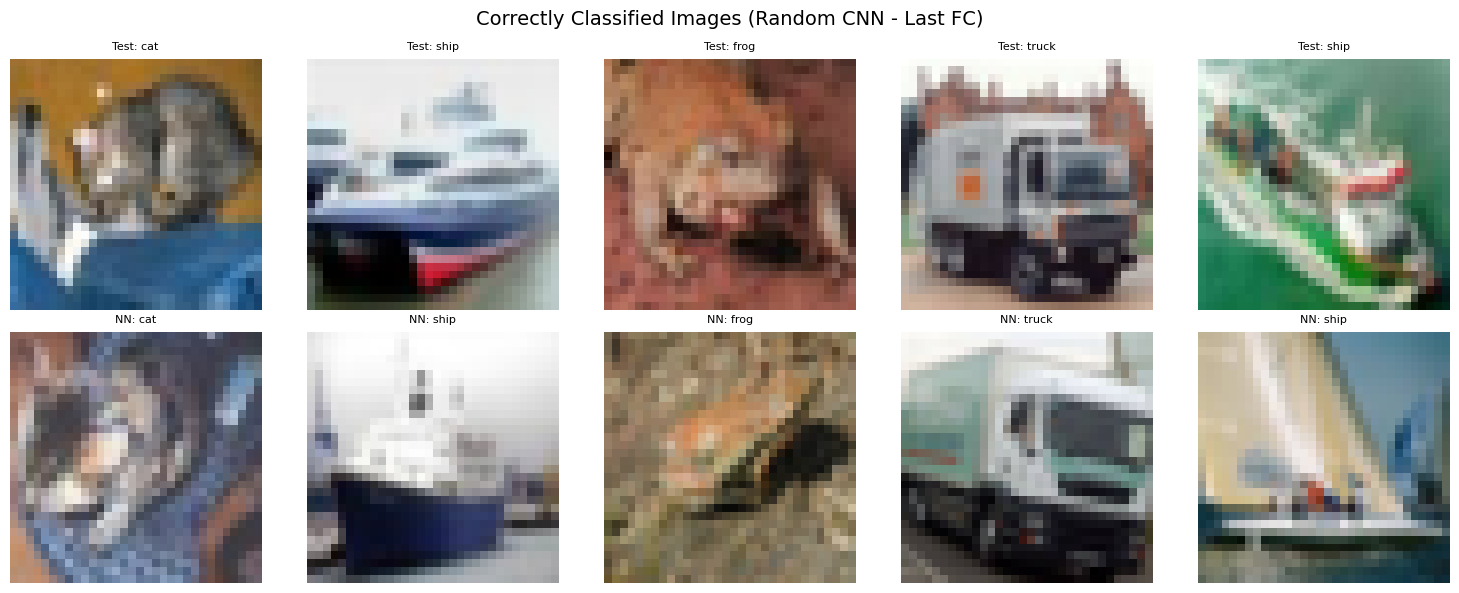

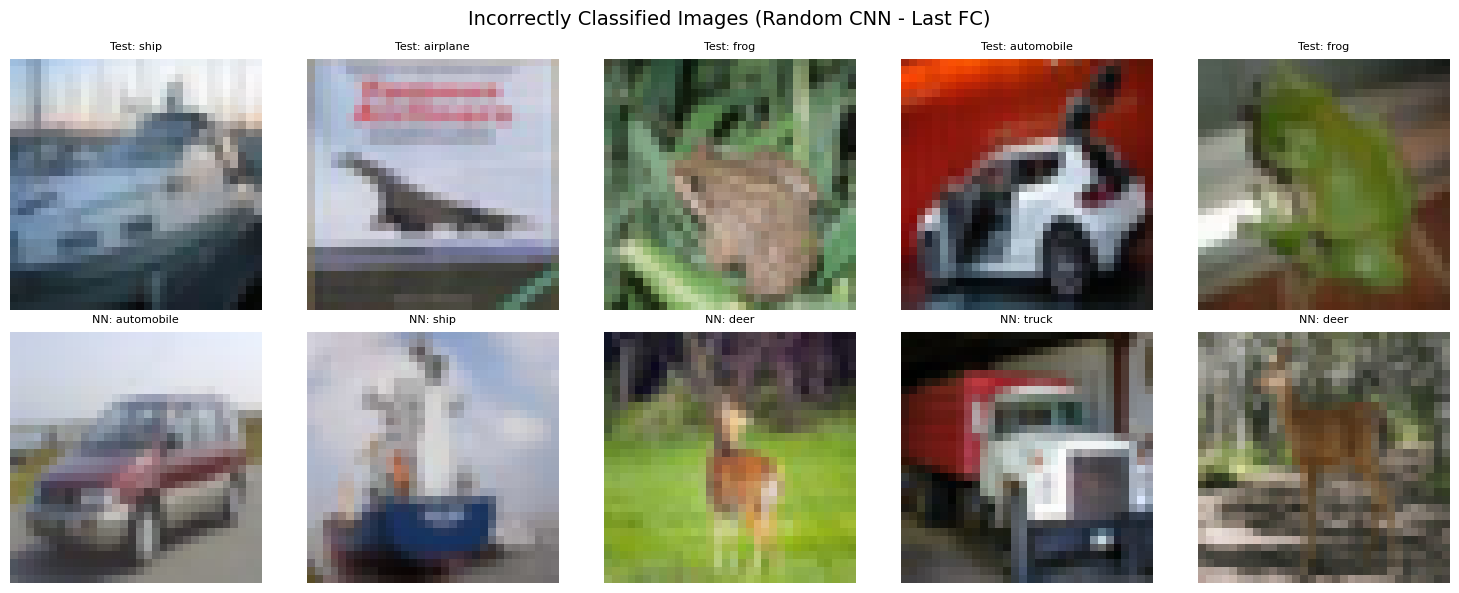

In [12]:
# compute or load features for random CNN at last_fc layer
random_cnn_train_features_last_fc, random_cnn_test_features_last_fc = compute_or_load_features(
    x_train, x_test, "random_cnn", layer="last_fc"
)

# run knn classifier on random CNN last_fc features and evaluate accuracy
random_cnn_knn_classifier_last_fc = run_nearest_neighbor(
    random_cnn_train_features_last_fc, y_train, random_cnn_test_features_last_fc, y_test
)

# visualize correctly and incorrectly classified images with their nearest neighbors
visualize_nearest_neighbors(
    x_test, y_test, x_train, y_train,
    random_cnn_knn_classifier_last_fc, random_cnn_test_features_last_fc,
    feature_name="Random CNN - Last FC"
)

## Project Summary

This project analyzes the impact of different image feature representations on classification performance using the CIFAR-10 dataset. We compare raw pixel values, Histogram of Oriented Gradients (HOG), and features extracted from both pretrained and randomly initialized VGG-11 convolutional neural networks. Each representation is evaluated using a k-nearest neighbor classifier to ensure a consistent and controlled comparison.

**Key Findings:**
- Deep features from pretrained CNNs achieve the highest classification accuracy, demonstrating the effectiveness of learned representations.
- HOG features outperform raw pixels, highlighting the value of classical feature engineering.
- Random CNN features outperform raw pixels but underperform pretrained features, indicating that both architecture and learned weights contribute to performance.

**Conclusion:**
Feature representation is a critical factor in image classification performance. While CNN architectures provide useful inductive bias, pretrained models significantly improve results by learning high-level semantic features. This project demonstrates the practical benefits of combining deep learning with simple classifiers for efficient and effective modeling.

## References

1. D. Ulyanov, A. Vedaldi, and V. Lempitsky, [Deep Image Prior](https://arxiv.org/pdf/1711.10925.pdf), CVPR 2018.
2. M. Zeiler and R. Fergus, [Visualizing and Understanding Deep Neural Networks](https://arxiv.org/pdf/1311.2901.pdf), ECCV 2014.  